In [25]:
from google.colab import files

uploaded = files.upload()

Saving Retail_Supply_Chain_Dataset_Large.xlsx to Retail_Supply_Chain_Dataset_Large (1).xlsx


In [26]:
import pandas as pd

sales = pd.read_excel(
    "Retail_Supply_Chain_Dataset_Large.xlsx",
    sheet_name="Sales_Data"
)

sales.head()

,OrderID,Date,Store,City,SKU,Product Name,Category,Qty,Unit Price,Supplier,Customer Name
0,1,2024-03-29,Store C,Faisalabad,SKU001,Shampoo 200ml,Personal Care,7,438,Unity Foods,Bilal Ahmed
1,2,2024-10-26,Store E,Islamabad,SKU008,Coffee 250g,Beverages,20,749,FreshCo Traders,Usman Tariq
2,3,2024-03-07,Store E,Lahore,SKU010,Butter 200g,Dairy,6,105,FreshCo Traders,Ali Khan
3,4,2024-09-13,Store A,Multan,SKU004,Chocolate Bar,Snacks,12,586,DailyNeeds,Bilal Ahmed
4,5,2024-12-25,Store E,Lahore,SKU009,Rice 5kg,Grocery,19,149,Metro Supplies,Sana Shah


In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
sales = pd.read_excel(
    "Retail_Supply_Chain_Dataset_Large.xlsx",
    sheet_name="Sales_Data"
)

In [29]:
print(sales.head())

print(sales.info())

print(sales.describe())

   OrderID        Date    Store        City     SKU   Product Name  \
0        1  2024-03-29  Store C  Faisalabad  SKU001  Shampoo 200ml   
1        2  2024-10-26  Store E   Islamabad  SKU008    Coffee 250g   
2        3  2024-03-07  Store E      Lahore  SKU010    Butter 200g   
3        4  2024-09-13  Store A      Multan  SKU004  Chocolate Bar   
4        5  2024-12-25  Store E      Lahore  SKU009       Rice 5kg   

        Category  Qty  Unit Price         Supplier Customer Name  
0  Personal Care    7         438      Unity Foods   Bilal Ahmed  
1      Beverages   20         749  FreshCo Traders   Usman Tariq  
2          Dairy    6         105  FreshCo Traders      Ali Khan  
3         Snacks   12         586       DailyNeeds   Bilal Ahmed  
4        Grocery   19         149   Metro Supplies     Sana Shah  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         -----

In [30]:
print(sales.isnull().sum())

OrderID          0
Date             0
Store            0
City             0
SKU              0
Product Name     0
Category         0
Qty              0
Unit Price       0
Supplier         0
Customer Name    0
dtype: int64


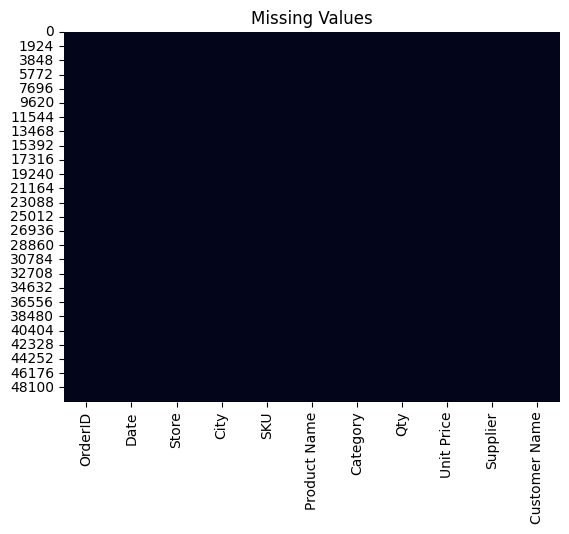

In [31]:
sns.heatmap(sales.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

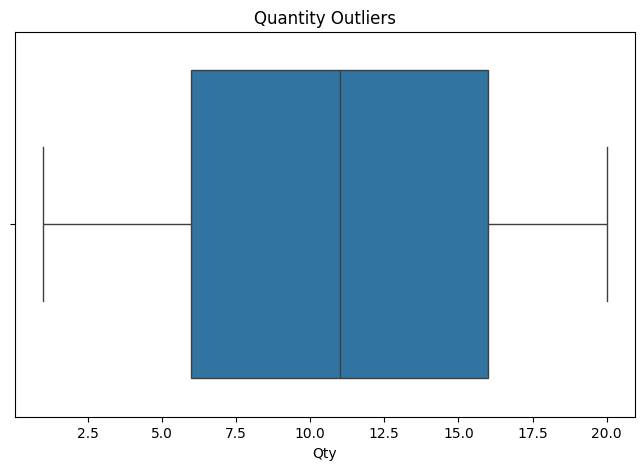

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=sales["Qty"]
)

plt.title("Quantity Outliers")
plt.show()

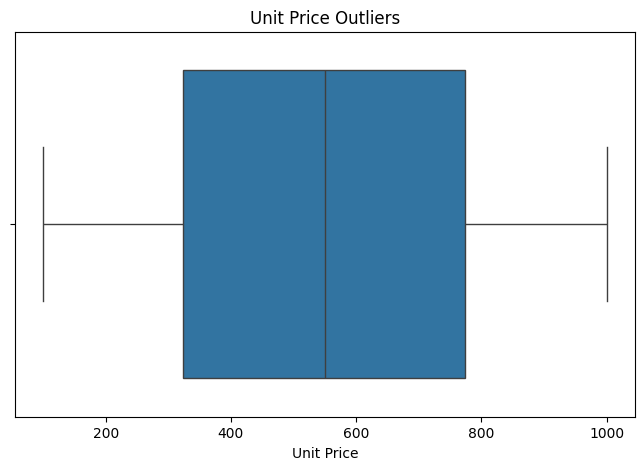

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=sales["Unit Price"]
)

plt.title("Unit Price Outliers")
plt.show()

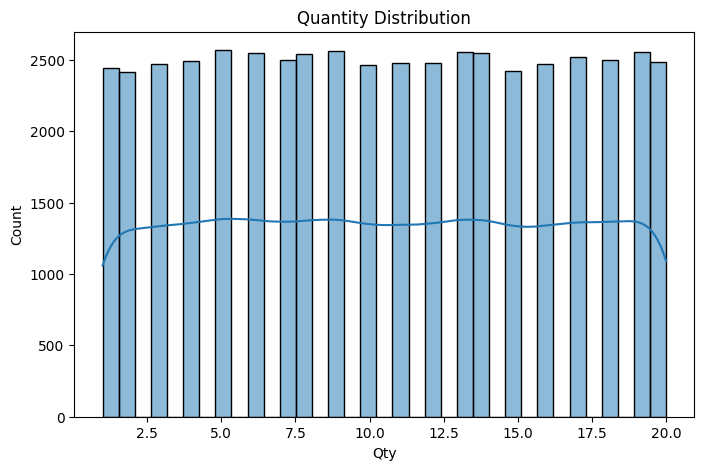

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(
    sales["Qty"],
    kde=True
)

plt.title("Quantity Distribution")
plt.show()

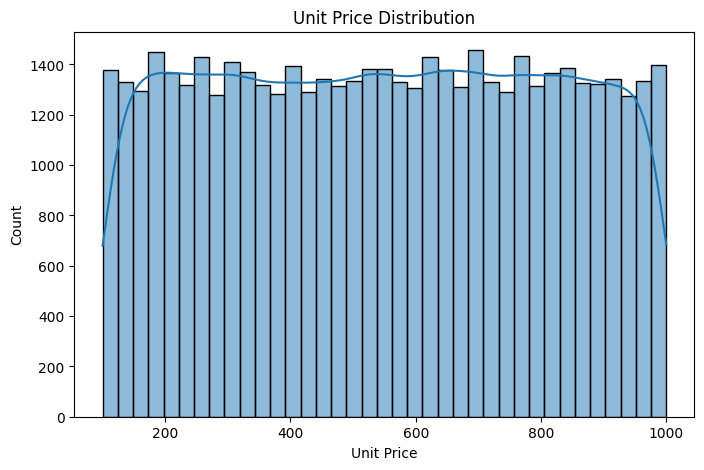

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(
    sales["Unit Price"],
    kde=True
)

plt.title("Unit Price Distribution")
plt.show()

In [36]:
Q1 = sales["Qty"].quantile(0.25)

Q3 = sales["Qty"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

print(lower, upper)

-9.0 31.0


In [37]:
sales_clean = sales[
    (sales["Qty"] >= lower)
    &
    (sales["Qty"] <= upper)
]

In [38]:
print("Before:", len(sales))

print("After:", len(sales_clean))

Before: 50000
After: 50000


In [39]:
numeric_cols = [
    "Qty",
    "Unit Price"
]

In [40]:
for col in numeric_cols:

    Q1 = sales[col].quantile(0.25)

    Q3 = sales[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    sales = sales[
        (sales[col] >= lower)
        &
        (sales[col] <= upper)
    ]

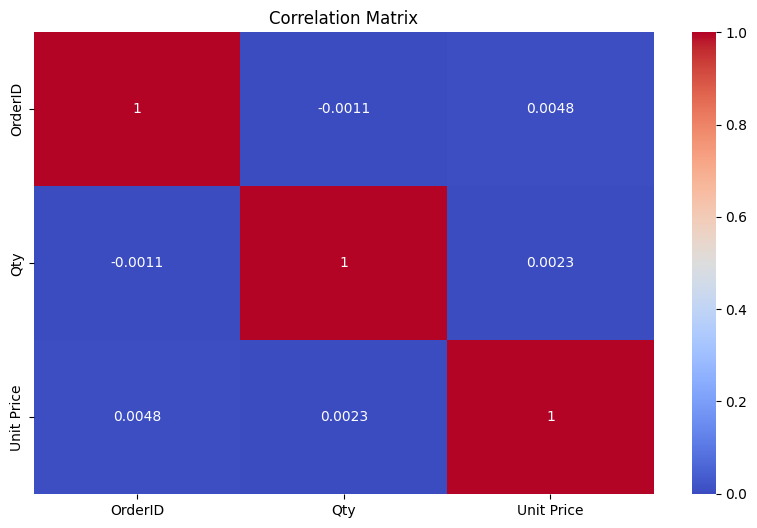

In [41]:
plt.figure(figsize=(10,6))

sns.heatmap(
    sales.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()